<a href="https://colab.research.google.com/github/SukhmanpreetKaurManes/My-learnings-from-Machine-Learning-with-Python-book/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn

In [27]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame

In [8]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


##Kmeans Algo

In [28]:
x = df.iloc[:, :4].values # All four feature columns
y_true = df['target'].values # The true target labels

Elbow method

In [11]:
from sklearn.cluster import KMeans

In [12]:
wcss = []
for i in range (1,11):
  kmeans = KMeans(n_clusters = i, init ='k-means++', random_state = 0)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)

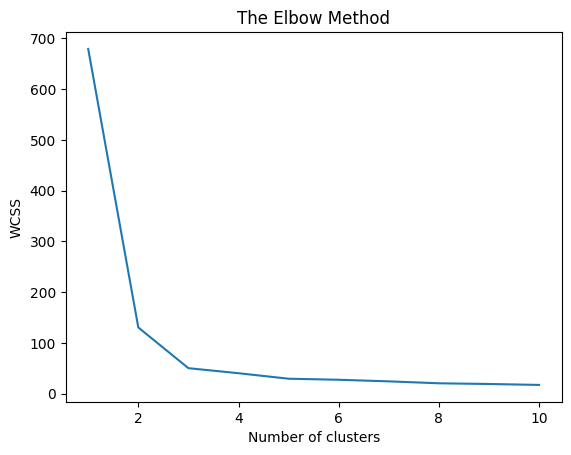

In [29]:
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Optimal no. of clusters = 3

In [30]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state =0)
y_kmeans =kmeans.fit_predict(x)

Visualizing the clusters

PCA can be used to find 2 most important attributes so that they can be represented on graph.Pair plots can be used to represent between combination of every 2 features.

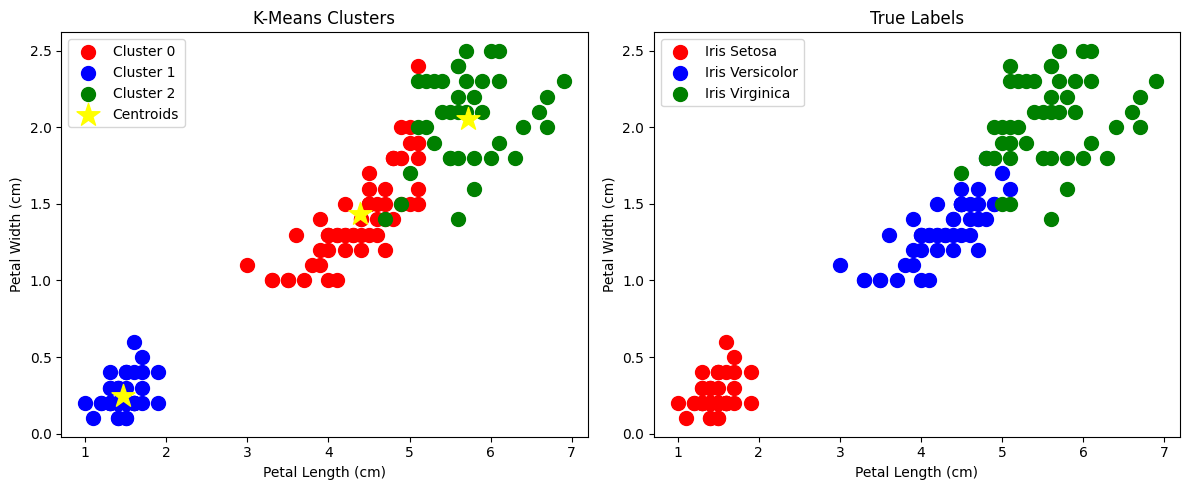

In [31]:
plt.figure(figsize=(12, 5))

# Plot K-Means Clusters
plt.subplot(1, 2, 1)
plt.scatter(x[y_kmeans == 0, 2], x[y_kmeans == 0, 3], s=100, c='red', label='Cluster 0')
plt.scatter(x[y_kmeans == 1, 2], x[y_kmeans == 1, 3], s=100, c='blue', label='Cluster 1')
plt.scatter(x[y_kmeans == 2, 2], x[y_kmeans == 2, 3], s=100, c='green', label='Cluster 2')
plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3], s=300, c='yellow', label='Centroids', marker='*')
plt.title('K-Means Clusters')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()

# Plot True Labels
plt.subplot(1, 2, 2)
plt.scatter(x[y_true == 0, 2], x[y_true == 0, 3], s=100, c='red', label='Iris Setosa')
plt.scatter(x[y_true == 1, 2], x[y_true == 1, 3], s=100, c='blue', label='Iris Versicolor')
plt.scatter(x[y_true == 2, 2], x[y_true == 2, 3], s=100, c='green', label='Iris Virginica')
plt.title('True Labels')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()

plt.tight_layout()
plt.show()

## Hierarchical Clustering

Constructing Dendrogram

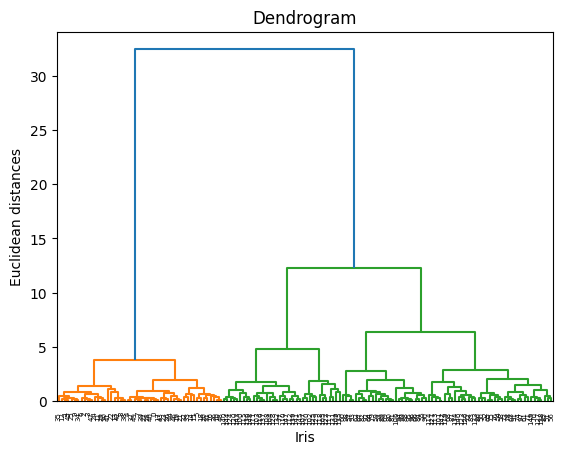

In [32]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(x,method='ward'))
plt.title('Dendrogram')
plt.xlabel('Iris')
plt.ylabel('Euclidean distances')
plt.show()

The 'ward' is a technique of clustering that uses minimum variance to cluster data points.

In [33]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 3, metric = 'euclidean', linkage = 'ward')
y_hc  = hc.fit_predict(x)

In [19]:
print(y_hc)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


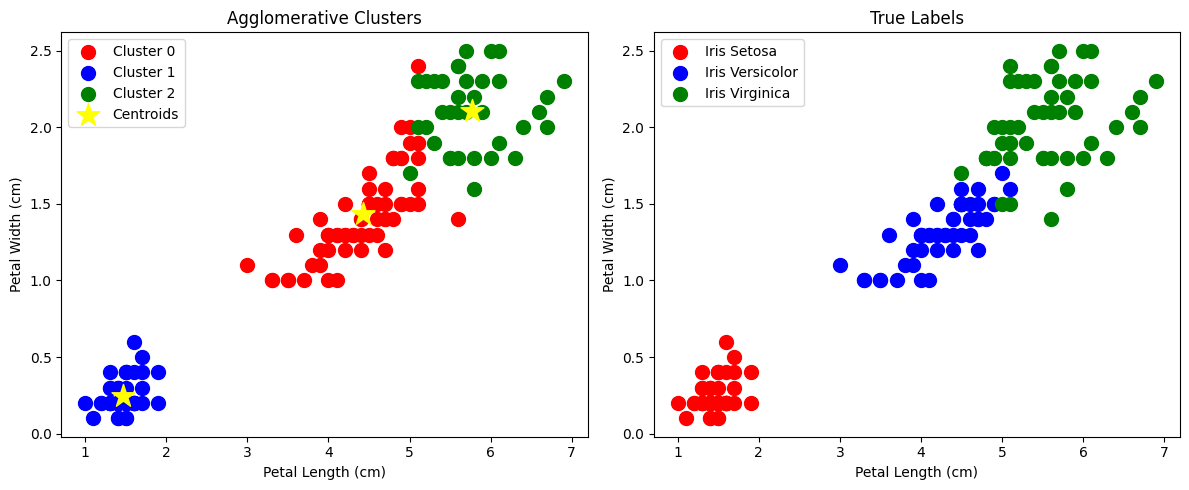

In [36]:
plt.figure(figsize=(12, 5))

# Plot Agglomerative Clusters
plt.subplot(1, 2, 1)
plt.scatter(x[y_hc == 0, 2], x[y_hc == 0, 3], s=100, c='red', label='Cluster 0')
plt.scatter(x[y_hc == 1, 2], x[y_hc == 1, 3], s=100, c='blue', label='Cluster 1')
plt.scatter(x[y_hc == 2, 2], x[y_hc == 2, 3], s=100, c='green', label='Cluster 2')
from sklearn.neighbors import NearestCentroid
clf = NearestCentroid()
clf.fit(x, y_hc)
centroids = clf.centroids_
plt.scatter(centroids[:, 2], centroids[:, 3], s=300, c='yellow', label='Centroids', marker='*')
plt.title('Agglomerative Clusters')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()

# Plot True Labels (re-using the same true label plot as above for comparison)
plt.subplot(1, 2, 2)
plt.scatter(x[y_true == 0, 2], x[y_true == 0, 3], s=100, c='red', label='Iris Setosa')
plt.scatter(x[y_true == 1, 2], x[y_true == 1, 3], s=100, c='blue', label='Iris Versicolor')
plt.scatter(x[y_true == 2, 2], x[y_true == 2, 3], s=100, c='green', label='Iris Virginica')
plt.title('True Labels')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()

plt.tight_layout()
plt.show()